<h1>Using Key Health Factors to Predict Heart Disease Via Logistic Regression</h1>

<p>This data set contains information on patients with and without heart disease.<br>
It uses five combined data sets from Cleveland, Hungary, Switzerland, Long Beach VA, and Stalog (Heart) Data Set, for a total of 918 observations.<br>
It includes variables such as age, sex, chest pain, blood pressure, etc which can be used to predict heart failure.<br>
It was downloaded from kaggle here: <a href="https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction">Dataset</a> (Fedesoriano, 2021).</p>

Heart disease is the second leading cause of death in Canada and the leading cause of death worldwide (Betai et al., 2024; Canada, 2017). It is defined as the buildup of plaque in one’s arteries and can have serious consequences, leading to heart attack or even death (Canada, 2017). Physiological risk factors of heart disease include high blood pressure, high cholesterol, being overweight or having diabetes (Alpert, 2023). Some people may be genetically predisposed to these risk factors, however they can also be caused or worsened by lifestyle factors including smoking, lack of exercise, and even air pollution (Alpert, 2023). 
Heart disease is more common in men, although women tend to develop heart disease about 10 years on average after men which is linked to the onset of menopause (Betai et al., 2024). Women and men can also have different presentations of symptoms of heart disease often including nausea, fatigue, and atypical chest pain with lack of research ultimately leading to a gender disparity in treatment outcomes for women (Betai et al., 2024). 


<a name="fig1"></a>  
<p align="left">
  <img src="./images/23074-heart-chambers.jpg" width="400">
</p>

**Figure 1.** Diagram of a Heart (Cleveland Clinic, 2022.).

In [56]:
#importing libraries
import numpy as np                       #working with numbers
import pandas as pd                      #working with data frames
import seaborn as sns                    #for plots
import matplotlib.pyplot as plt          #for plots
from scipy.stats import linregress       #for plots
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler   #to preprocess data
from sklearn.model_selection import train_test_split             #to split dataset
from sklearn.metrics import roc_curve, auc, precision_score, accuracy_score, recall_score, f1_score                #used for roc curve and auc calculation
from sklearn.exceptions import UndefinedMetricWarning           #for catching warnings about precision calculation at low thresholds

import statsmodels.formula.api as smf                           #to fit logistic regression model
from statsmodels.stats.outliers_influence import variance_inflation_factor  #to calculate VIFs

from matplotlib_venn import venn3       #for venn diagrams

<h2>Exploratory Data Analysis</h2>

In [2]:
#read in file
hd_df = pd.read_csv("heart_disease.csv")
hd_df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


Next, we will take a look at the columns and data types within them.

In [3]:
#looking at columns and data types
print(list(hd_df.columns))   #columns
print("df shape", hd_df.shape) #size
hd_df.dtypes.to_frame().T      #data types

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
df shape (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,int64,object,object,int64,int64,int64,object,int64,object,float64,object,int64


There are 12 columns with 918 entries (rows) for each. Some of the columns are numerical (integers or floats), while the others are object (strings).
<br><br>
Next we will remove any null or missing values

In [4]:
#checking for NAs
hd_df.isna().sum().to_frame().T   #There are no missing values. Nice.

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
#looking for duplicates
hd_df.duplicated().sum()  #no duplicates!


np.int64(0)

Fortunately, there are no null values or duplicates to remove.<br>
Next, we will take a look at the specific values within each column to get a better idea of the variables we are working with.


In [6]:
#looking at the categorical variables and the range (min and max) in the numerical columns
for col in hd_df.columns:
  print(col)
  if len(hd_df[col].unique()) > 5:
    print(hd_df[col].min(), hd_df[col].max(), "\n")
  else:
   print(hd_df[col].unique(), "\n")

Age
28 77 

Sex
['M' 'F'] 

ChestPainType
['ATA' 'NAP' 'ASY' 'TA'] 

RestingBP
0 200 

Cholesterol
0 603 

FastingBS
[0 1] 

RestingECG
['Normal' 'ST' 'LVH'] 

MaxHR
60 202 

ExerciseAngina
['N' 'Y'] 

Oldpeak
-2.6 6.2 

ST_Slope
['Up' 'Flat' 'Down'] 

HeartDisease
[0 1] 



Above, I have displayed the min and max values for numerical columns and all of the unique values for the categorical columns.


As you can see, the categorical variables or 'object' columns all contain strings which represent a specific category within a column. For the 'Sex' column, "M" and "F" stand for male and female, respectively. The 'ChestPainType' categories are: Typical Angina ("TA"), Atypical Angina ("ATA"), Non-Anginal Pain ("NAP"), and Asymptomatic ("ASY"). The 'RestingECG' refers to an electrocardiogram of a patient in a resting state. The categories are: "Normal", "ST", meaning having ST-T wave abnormality (<a href="#ecg">Figure 2</a>), and "LVH" showing left ventricular hypertrophy. The 'ExcerciseAngina' column has two options, 'Y' or 'N', indicating if the patient does develop excercise induced angina or not. 'ST_Slope' depicts the slope of the line at the ST wave on an ECG (<a href="#ecg">Figure 2</a>). The categories are "Up", "Flat" and "Down", where a normal/healthy ST wave is flat and an upwards or downwards slope can indicate myocardial ischemia or infarction (Burns & Buttner, 2024).


For the numerical variables, 'Age' is measured in years, 'RestingBP' is resting systolic blood pressure measured in mm Hg, 'Cholesterol' is total cholesterol measured in mg/dL and 'MaxHR' is maximum heart rate in BPM (beats per minute). 'Oldpeak' is taken from an ECG, and indicates how the heart responds to physical excertion relative to the resting state (Al Ahdal et al., 2023). It is the slope of the ST depression, where negative slopes and elevated slopes are indicative of heart attacks (<a href="#ecg">Figure 2</a>) (Burns & Buttner, 2024).


The two columns, 'HeartDisease' and 'FastingBS' are technically numerical, but they contain 1s and 0s which represent binary categories.  The 'FastingBS' column indicates if the patient's fasting blood sugar level is above 120 mg/dL (1) or below 120 mg/dL (0). Lastly, the 'HeartDisease' column is the actual diagnosis of the patient and the target variable, with 1 indicating heart disease, and 0 indicating no heart disease.

<figure id="ecg">
<p align="left">
  <img src="./images/Electrocardiogram-ECG.webp" width="400">
  <figcaption><strong>Figure 2.</strong> A typical ECG with labelled segments (MicrobeNotes, 2024).</figcaption>
</p>
</figure>

We will take a look at the distribution of the numerical variables using histogram plots.

In [7]:
#function to make histogram plots
def histogram_plots(x, xlab, title, binwidth, i):
    p = sns.histplot(data = hd_df, x = x, binwidth = binwidth, ax=axes[i])
    p.set_title(title) 
    p.set_xlabel(xlab)
    return p

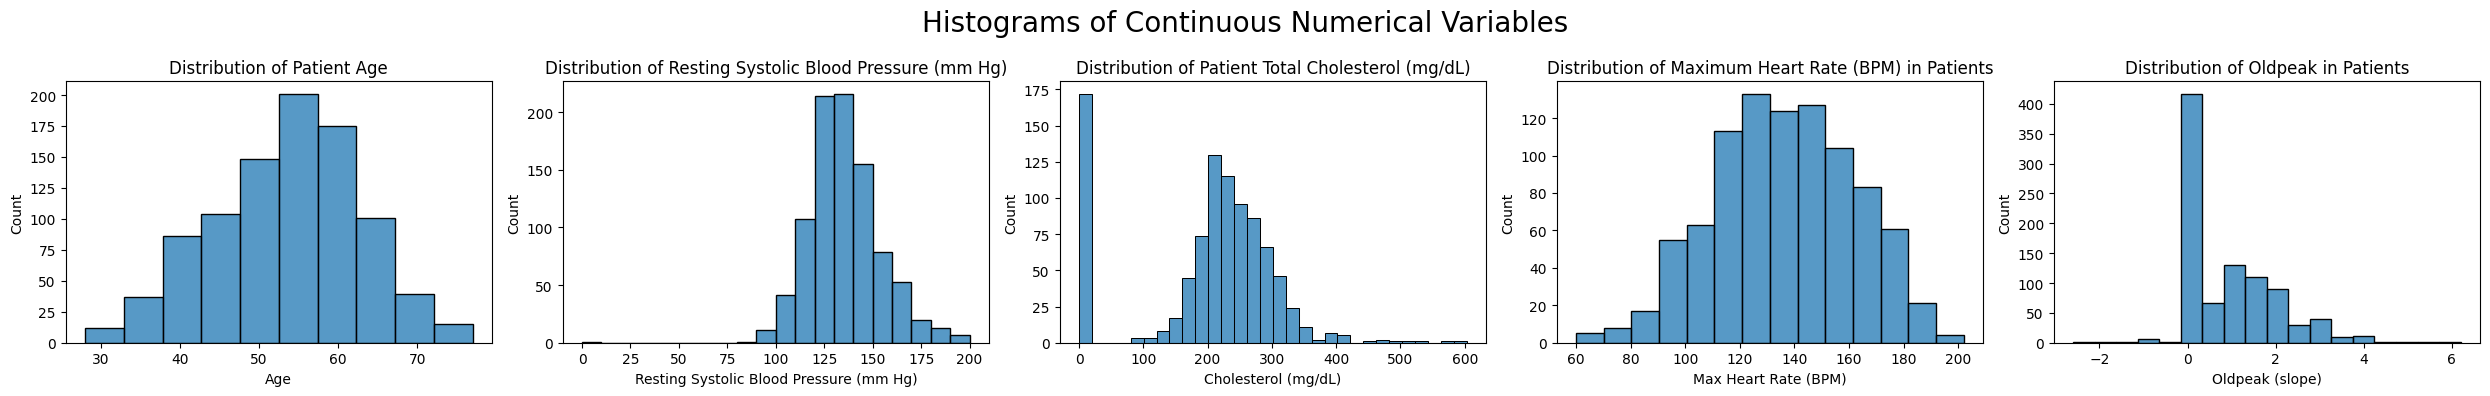

In [8]:
fig, axes = plt.subplots(nrows = 1, ncols = 5, figsize=(25,4))
axes = axes.flatten()

#get only continuous numerical values
num_df = hd_df.select_dtypes(np.number).drop(columns = ["FastingBS", "HeartDisease"])
#print(num_df.columns.tolist())

#adjust titles and binwidths
titles = ["Distribution of Patient Age", "Distribution of Resting Systolic Blood Pressure (mm Hg)", "Distribution of Patient Total Cholesterol (mg/dL)",
           "Distribution of Maximum Heart Rate (BPM) in Patients", "Distribution of Oldpeak in Patients"]
xlabs = ["Age", "Resting Systolic Blood Pressure (mm Hg)", "Cholesterol (mg/dL)", "Max Heart Rate (BPM)", "Oldpeak (slope)"]
binwidths = [5,  10, 20, 10, 0.5]

#make plots
for i in range(len(num_df.columns)):
    histogram_plots(num_df.columns[i], xlabs[i], titles[i], binwidths[i], i)

fig.suptitle("Histograms of Continuous Numerical Variables", fontsize = 20)
plt.tight_layout()
plt.show()

For most of the numerical variables, the majority of patients have values in the center of the distribution, with the more extreme values tapering out further from the center. This comes with some exceptions of course. For example, for 'Age', the majority of the entries are between 40 and 65, with a slight left-skew, and steeper drop off after 65. the cholesterol distribution has many entries with a cholesterol of 0, this is not biologically possible, so many of these values will have to be removed. Overlooking this, the rest of the cholesterol entries peak around 220, with the majority being between 200 and 300 mg/dL and tapering off beyond these values. The 'MaxHR' data are also slightly left-skewed, with a large range of entries being almost evenly distributed between the ranges of 110 to 170 bpm. Resting blood pressure has a few values which contain a majority of the data including 120, 125, and 140ish. This makes sense as typical healthy systolic blood pressures are between 110 and 120, with slightly elevated BPs being above 120 (American Heart Association, 2025). The remainder of this data is mostly between 100 - 160 mm Hg. For 'oldpeak' the most common value is 0. This makes sense, as a healthy ST-wave is flat and would have a slope of 0 (Al Ahdal et al., 2023 ; Yazdani et al., 2021). Aside from this, the data for 'oldpeak' is randomly distributed with most of the other entries being above 0, but a few entries being below 0.

In [9]:
#changing Cholesterol == 0 to NAs
hd_df["Cholesterol"] = hd_df["Cholesterol"].replace(0, np.nan)
print("Number of Cholesterol = 0 entries: ", int(hd_df.Cholesterol.isna().sum()))
hd_df = hd_df.dropna()  #unfortunately having to remove these columns
print("New number of entries:", hd_df.shape[0])

Number of Cholesterol = 0 entries:  172
New number of entries: 746


Next we will take a look at the distributions of our categorical variables.

In [10]:
# representing categorical variables as pie charts
def makepieplot(df, column, title, a):
  data = df[column].value_counts().tolist()
  label = df[column].unique()
  c = ["blue", "orange", "green", "red", "yellow", "purple", "pink"][0:len(label)]
  a.pie(data, labels=label, startangle=90, autopct='%1.1f%%', colors = c) #, ax=axes[axes_ind])
  a.set_title(title)
  return a

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease', 'FastingBS']


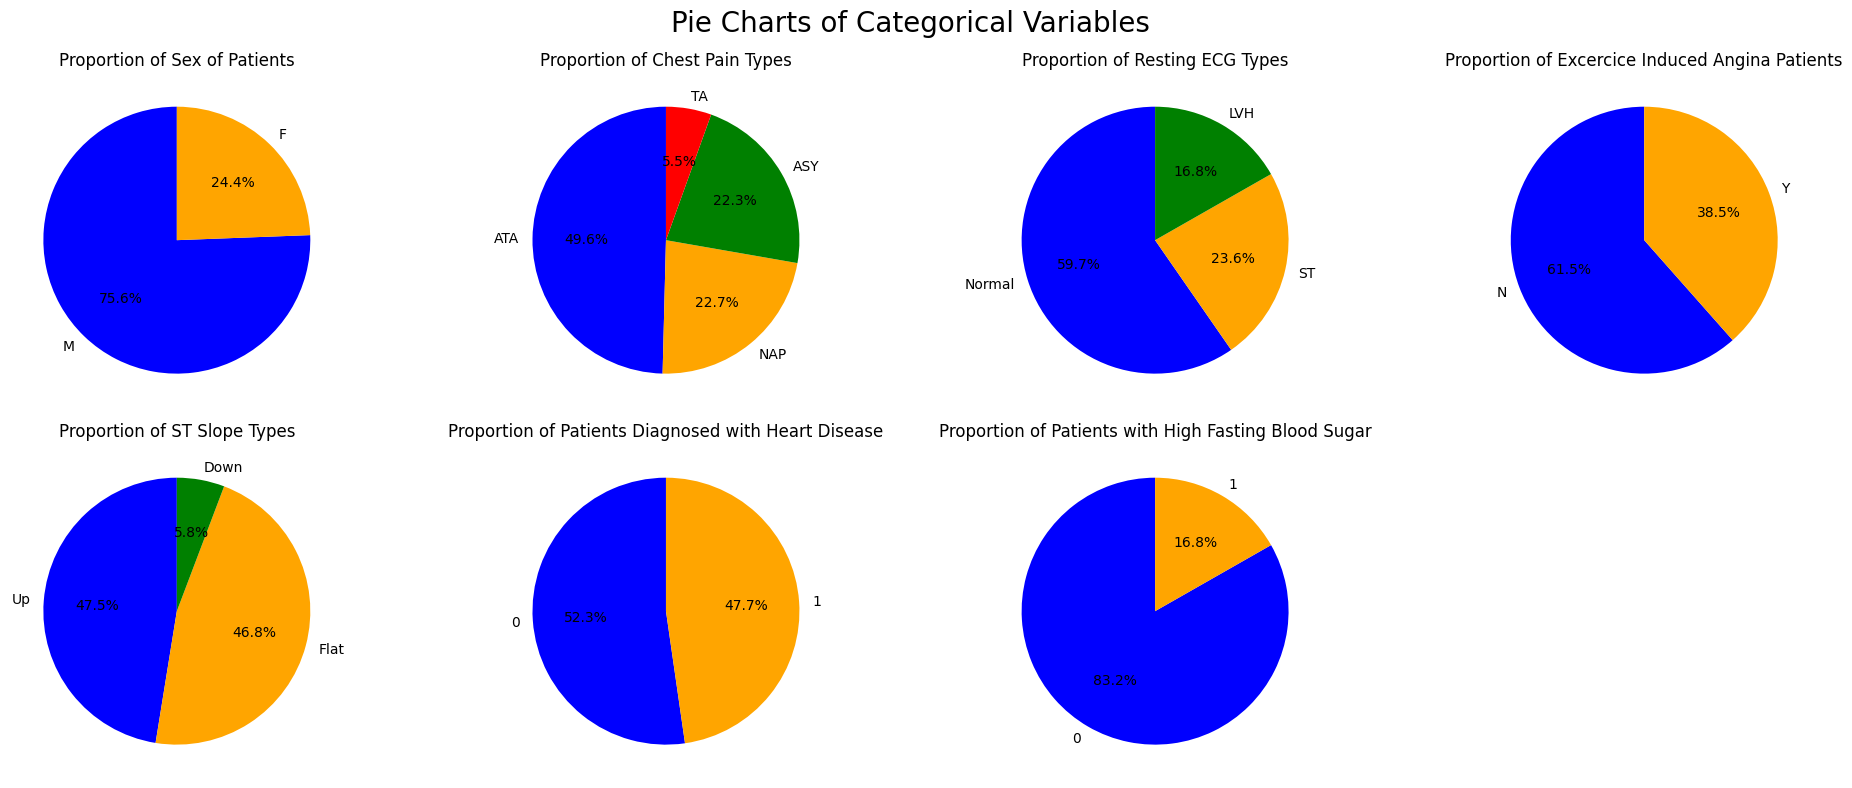

In [11]:
fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (20,8))
axes = axes.flatten()

hd_category = hd_df.select_dtypes(object).columns.tolist() + ["HeartDisease", "FastingBS"]  #data frame with categorical variables
print(hd_category)
titles = ["Proportion of Sex of Patients", "Proportion of Chest Pain Types", "Proportion of Resting ECG Types",
          "Proportion of Excercice Induced Angina Patients", "Proportion of ST Slope Types",
          "Proportion of Patients Diagnosed with Heart Disease", "Proportion of Patients with High Fasting Blood Sugar"]

for i in range(0, len(hd_category)):
  makepieplot(hd_df, hd_category[i], title = titles[i], a = axes[i])

plt.delaxes(axes[7])

fig.suptitle("Pie Charts of Categorical Variables", fontsize = 20)
plt.tight_layout()
plt.show()

Describing the categorical distributions above:
* Males are almost 3 times as common as females in this dataset
* ST slopes have few downward slopes and an almost equal amount of normal slopes and upward slopes. This means an even amount of healthy looking ECGs to unhealthy ECGs.
* Chest Pain Types: Asymptomatic is as common as Atypical Angina and Non-Anginal Pain combined. While Typical Angina pain is not very common at all. This is good as typical angina is most commonly associated with ischemic heart disease, although this could be dangerous as asymtomatic angina can still be an indication of heart disease and can sometimes cause a "silent ischemia" (American Heart Association, 2024b ; Dancy et al., 2018).
* Fasting Blood Sugar: The majoirty of patients have a fasting blood sugar greater than 120 mg/dL. While only about 1/7 patients are under 120 mg/dL. This is dangerous as high fasting glucose levles are linked to ischemic heart disease and diabetes. Also a high fasting glucose is associated with high blood pressure and cholesterol (Park et al., 2013).
* ECG Type: Most Patients have a normal ECG type which is good. About 300 in total have either an ST or LVH type which could potentially indicate heart disease.
* Excercise Induced Angina: More people do not have excercise induced angina than people who do. Still about 300 do have it which means there is a reduced blood flow to the heart during excercise. This of course indicates an unhealthy cardiovascular system and is a potential indicator of heart disease.
* Heart Disease: Lastly, slightly over half of individuals do not have heart disease, compared to around 350 patients who were in fact diagnosed with heart disease.

<h2>Data Preprocessing</h2>

To preprocess the data bfore training the model a few steps need to occur. First, I will encode my categorical variables which have greater than 2 variables using one-hot encoding. Encoding in general is necessary because the logistic regression model requires a numeric input as it can not interpret a string. One-hot encoding is specifically necessary here because these variables are nominal, meaning they do not have a specific order to them. Hence, we cannot use label encoding here as this would imply a relationship between the variables within each category which could mislead the model. I am not including the categories with only 2 variables as these can be binary encoded and one-hot encoding would result in one column being redundant.
Second, I will split the data into training and test sets before doing any scaling so as not to leak information from the test set into my training test. I will split the training:test by 80:20 because this will give us ample data to train the model. The split will of course be random so as not to impose bias on the model. Lastly, I will scale the model. Although scaling is not required for logistic regressions, it will be helpful for model performance in this case because some variables such as cholesterol and oldpeak have very different ranges. Cholesterol goes up to 600 and oldpeak goes up to 6. Thus standardization will help the model to converge especially considering we have so many variables.

In [12]:
#Perform label encoding, one-hot encoding on categorical variables, split data into test and training sets, and scaling on continuous numerical variables
#pd.set_option('future.no_silent_downcasting', True) 

def preprocessing(df):

    #1. one-hot encode columns with > 2 subcategories
    one_hot_columns = df.select_dtypes(object).drop(columns=["Sex", "ExerciseAngina"]).columns  #these are the columns we will get dummy variables for
    print("Columns undergoing one-hot encoding:", list(one_hot_columns))

    # drop one dummy variable for each one-hot category.
    #'neutral' columns are dropped
    drop_dummies = ['ChestPainType_TA', "ST_Slope_Flat", "RestingECG_Normal"]
    dummies = pd.get_dummies(df[one_hot_columns])    
    dummies = dummies.drop(columns=drop_dummies) 
    print("Dropping dummy variables: ", drop_dummies)

    # recombine with dataframe, and drop old columns
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(columns=one_hot_columns)

    #2.  Label encode columns with 2 subcategories
    le_excercise_angina = LabelEncoder()
    le_sex = LabelEncoder()
    df["ExerciseAngina"] = le_excercise_angina.fit_transform(df["ExerciseAngina"])
    df["Sex"] = le_sex.fit_transform(df["Sex"])
    print("Sex Classes (0, 1):", le_sex.classes_)
    print("Angina Classes (0, 1):", le_excercise_angina.classes_)

    #change boolean back to integer
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(int)

    #3.  Separate into train and test datasets
    #splitting dataframe into 80% training and 20% testing.
    xtrain, xtest, ytrain, ytest = train_test_split(df.drop(columns=["HeartDisease"]), df["HeartDisease"], test_size = 0.2, random_state = 10)

    #combine x and y into train and test data frame
    df_train = pd.concat([xtrain, ytrain], axis=1)
    df_test = pd.concat([xtest, ytest], axis=1)

    print("training data: n =",len(xtrain))
    print("test data: n =",len(xtest))

    #4. Scale continuous numerical variables
    scale_columns = ["RestingBP", "Age", "MaxHR", "Oldpeak", "Cholesterol"]    #list of columns we are going to transform
  
    scale = StandardScaler()       #initializing scaling object
    df_train[scale_columns] = scale.fit_transform(df_train[scale_columns])  #only fit to the training set, then transform it
    df_test[scale_columns] = scale.transform(df_test[scale_columns])        #transform the test data according to the training set

    return (df_train, df_test)

In [13]:
df_train, df_test = preprocessing(hd_df)

Columns undergoing one-hot encoding: ['ChestPainType', 'RestingECG', 'ST_Slope']
Dropping dummy variables:  ['ChestPainType_TA', 'ST_Slope_Flat', 'RestingECG_Normal']
Sex Classes (0, 1): ['F' 'M']
Angina Classes (0, 1): ['N' 'Y']
training data: n = 596
test data: n = 150


<h2>Checking Multicollinearity Assumptions<h2>

One assumption of using logistic regressions is that there is no multicollinearity present. Multicollinearity occurs when two or more predictors in a model are highly correlated. This cause coefficient estimates to change drastically and lead to a biased model interpretation. In statistics calculating the Variance Inflation Factor (VIF) is a way of detecting multicollinearity. VIF values below 5 indicate little to no multicollinearity.

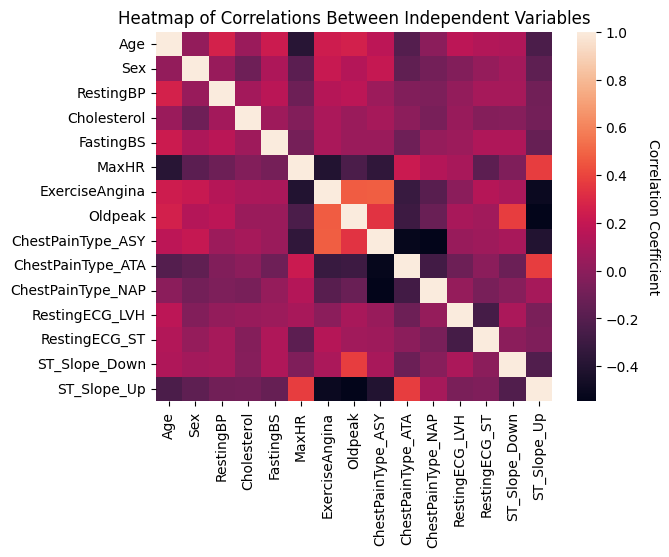

In [14]:
p = sns.heatmap(df_train.drop(columns=["HeartDisease"]).corr())
p.set_title("Heatmap of Correlations Between Independent Variables")

cbar = p.collections[0].colorbar
cbar.set_label("Correlation Coefficient", labelpad=15, rotation=270)
plt.show()

Above we can see variables which have moderate to high correlations. It appears excercise angina is most highly correlated with oldpeak and asymptomatic chest pain type. We will see if this correlation is significant enough to be removed using our VIF calculation.

In [15]:
#VIF calculation, takes df with target variable removed.
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data['variable'] = df.columns
    # calculating VIF for each feature
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data.sort_values(by='VIF', ascending=False)

X = df_train.drop('HeartDisease', axis=1) #independent variables
print(calculate_vif(X))

             variable       VIF
8   ChestPainType_ASY  4.274306
1                 Sex  3.979170
14        ST_Slope_Up  3.024867
6      ExerciseAngina  2.830079
9   ChestPainType_ATA  2.211288
10  ChestPainType_NAP  2.041364
7             Oldpeak  1.799311
11     RestingECG_LVH  1.517414
5               MaxHR  1.493952
0                 Age  1.410852
12      RestingECG_ST  1.365901
4           FastingBS  1.344483
13      ST_Slope_Down  1.264820
2           RestingBP  1.120641
3         Cholesterol  1.055545


All variables have a VIF value of less than 5. This means that there is little multicollinearity, so we may proceed with creating our model without needing to remove variables.

We will fit all of our possible predictive variables into our model initially to create our full model. From here we will modify our model based off of which variables appear to be significant or insignificant.

In [16]:
#performing a logistic regression

#get x variables
x_vars = list(df_train.drop(columns=["HeartDisease"]).columns)
x_vars = " + ".join(x_vars)
print("Input variables for logistic regression model:\n", x_vars, "\n")    #I will put these into the logistic regression model

#create the formula
f = "HeartDisease ~" + x_vars

#1 define model
HD_logit = smf.logit(formula = f, data = df_train).fit() #fit model to training data
print(HD_logit.summary()) 

Input variables for logistic regression model:
 Age + Sex + RestingBP + Cholesterol + FastingBS + MaxHR + ExerciseAngina + Oldpeak + ChestPainType_ASY + ChestPainType_ATA + ChestPainType_NAP + RestingECG_LVH + RestingECG_ST + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.311408
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  596
Model:                          Logit   Df Residuals:                      580
Method:                           MLE   Df Model:                           15
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.5507
Time:                        12:21:47   Log-Likelihood:                -185.60
converged:                       True   LL-Null:                       -413.10
Covariance Type:            nonrobust   LLR p-value:                 1.809e-87
          

When comparing the p-values to a cuttoff of &alpha; = 0.05, the non-significant variables are RestingBP (resting blood pressure), FastingBS (fasting blood sugar), MaxHR (max heart rate), and RestingECG (LVH and ST).<br>
Cholesterol is nearly significant, so I will leave it in the model to see if significance improves upon the removal of the above variables.<br>
Although, ChestPainType_ATA and ChestPainType_NAP are well above 0.05, ChestPainType_ASY is significant (p-value of 0.003), hence all of these dummy variables will remain in the model.

Now we will create a valid, reduced model by re-fitting the model without the non-significant variables.

In [17]:
#get x variables
non_sig_vars = ["RestingECG_LVH", "RestingECG_ST"] + ["RestingBP", "FastingBS", "MaxHR"] #these variables will be removed
df_reduced = df_train.drop(columns=non_sig_vars) #make new data frame with reduced variables.

x_vars2 = list(df_reduced.drop(columns=["HeartDisease"]).columns)
x_vars2_str = " + ".join(x_vars2)
print("Input variables for logistic regression model:\n", x_vars2_str, "\n")    #I will put these into the logistic regression model

# #create the formula
f = "HeartDisease ~" + x_vars2_str

#define model
HD_logit_reduced = smf.logit(formula = f, data = df_reduced).fit() #fit model to training data
print(HD_logit_reduced.summary()) 

Input variables for logistic regression model:
 Age + Sex + Cholesterol + ExerciseAngina + Oldpeak + ChestPainType_ASY + ChestPainType_ATA + ChestPainType_NAP + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.313722
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  596
Model:                          Logit   Df Residuals:                      585
Method:                           MLE   Df Model:                           10
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.5474
Time:                        12:21:47   Log-Likelihood:                -186.98
converged:                       True   LL-Null:                       -413.10
Covariance Type:            nonrobust   LLR p-value:                 6.925e-91
                        coef    std err          z      P>|z|      [0.025  

Above is the reduced model with all significant variables. Below is a chart to better visualize the direction and magnitude of influence of each variable.

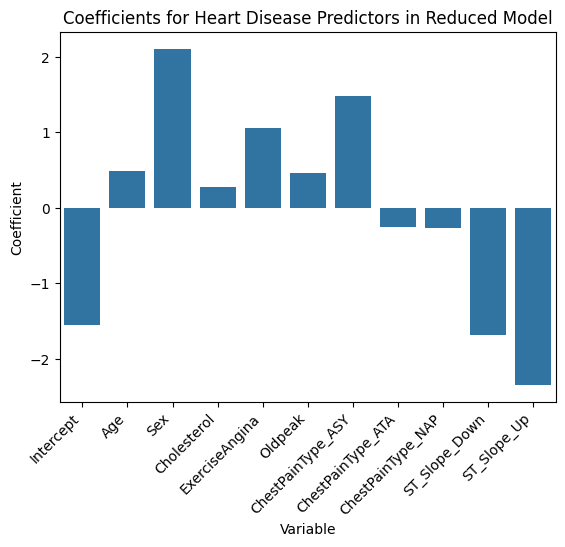

In [18]:
#create data frame
x = HD_logit_reduced.params.index.tolist()
y = HD_logit_reduced.params
df_coefs = pd.DataFrame({"variable":x, "coefficient":y})

#make plot
p = sns.barplot(data = df_coefs, x = "variable", y = "coefficient")

#fix labels
p.set_xlabel("Variable")
p.set_ylabel("Coefficient")
plt.setp(p.get_xticklabels(), rotation=45, ha='right')
p.set_title("Coefficients for Heart Disease Predictors in Reduced Model")

plt.show()

As you can see, sex has the largest positive influence on a heart disease diagnosis. Given that men were encoded as 1, this means that being male is the largest predictor of a patient having heart disease.<br>
Interestingly, having an upward ST slope is the largest indicator of a patient not having heart disease.

Next, I will improve upon the model by checking for significant interaction terms and higher order terms.

In [19]:
## Testing Interaction Terms
# create the formula
# f = "HeartDisease ~ " + x_vars2_str + "+ Sex*ChestPainType_ASY"

# # #define model
# HD_logit_int = smf.logit(formula = f, data = df_reduced).fit() #fit model to training data
# print(HD_logit_int.summary()) 

In [20]:
## Testing Higher Order Terms
# f = "HeartDisease ~ " + x_vars2_str + "+ I(Cholesterol**2) + I(Age**2) + I(Oldpeak**2)"

# # # #define model
# HD_logit_higher = smf.logit(formula = f, data = df_reduced).fit() #fit model to training data
# print(HD_logit_higher.summary()) 

The above tests have been commented out as there are no significant interaction terms. 
As well, there are no significant higher order terms. This means our reduced model is our final model.<br>
Now we will test our model to see how accurately it can predict heart disease on our test dataset.

In [21]:
# 1. Function to make predictions for heart disease given a specific model and decision threshold
def make_predictions(model, df, threshold):
    prob = model.predict(df)
    pred = prob >= threshold
    pred = pred.astype(int)
    pred = pd.DataFrame({"prob":prob, "pred":pred})
    return pred

In [22]:
#1. make predictions on test data set
test_pred = make_predictions(HD_logit_reduced, df_test, 0.5)
test_info = pd.DataFrame({"actual":df_test.HeartDisease, "type":["test"]*len(test_pred)})
test_pred = pd.concat([test_pred, test_info], axis=1)

# 2. Make predictions on training data to compare for overfitting
train_pred = make_predictions(HD_logit_reduced, df_train, 0.5)
train_info = pd.DataFrame({"actual":df_train.HeartDisease, "type":["train"]*len(train_pred)})
train_pred = pd.concat([train_pred, train_info], axis=1)

# combine dataframes
all_predictions = pd.concat([train_pred, test_pred])

In [23]:
# a function to count true negatives and false positives ets, given a dataframe with the name of the column containin the predictions and the name of the column containing the true values
#returns a dictionary of counts
def determine_accuracy(df, pred, target):
  TP = ((df[pred] == 1) & (df[target] == 1)).sum()
  FP = ((df[pred] == 1) & (df[target] == 0)).sum()
  TN = ((df[pred] == 0) & (df[target] == 0)).sum()
  FN = ((df[pred] == 0) & (df[target] == 1)).sum()

  return {"TN":TN, "TP":TP, "FN":FN, "FP":FP}

#this function makes a confusion matrix based on the same data from determine_accuracy()
def makematrix(df, pred, target, title):

  conf_matrix = determine_accuracy(df, pred, target)
  conf_matrix = pd.DataFrame([[conf_matrix["TN"], conf_matrix["FP"]], [conf_matrix["FN"], conf_matrix["TP"]]], columns=[0,1], index=[0,1])
  
  p = sns.heatmap(conf_matrix, annot=True, cmap="coolwarm", fmt="g")
  p.set_xlabel("Predicted Values")
  p.set_ylabel("Actual Values")
  p.set_title(title)
  return p

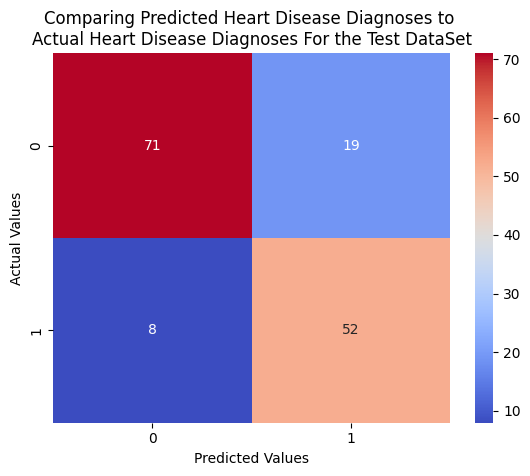

In [24]:
#show confusion matrix for test data
scores = makematrix(test_pred, pred = "pred", target = "actual", title = "Comparing Predicted Heart Disease Diagnoses to \nActual Heart Disease Diagnoses For the Test DataSet")
plt.show()


Above is a confusion matrix, showing the number of true positive, false positive, true negative, and false negative predictions. It appears that true positive and true negative predictions shave the highest counts. We can further visualize this by computing precision, accuracy, recall, and F1 score metrics.

In [59]:
def metric_scores(ytrue, ypred, modelname):
  pr = precision_score(ytrue, ypred, zero_division=0)
  ac = accuracy_score(ytrue, ypred)
  rc = recall_score(ytrue, ypred)
  f1 = f1_score(ytrue, ypred)

  df = pd.DataFrame({"model":[modelname], "pr":[pr], "ac":[ac], "rc":[rc], "f1":[f1]})
  return df

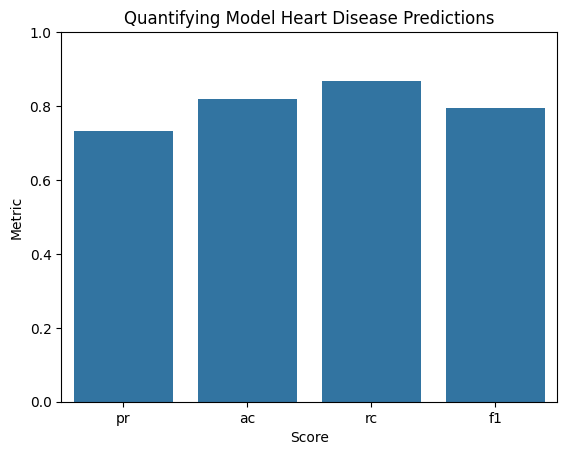

In [48]:
m = metric_scores(test_pred.actual, test_pred.pred, "reduced_model")
m_df = pd.DataFrame({"metric":m.columns[1:].tolist(), "score":m.iloc[0,1:].tolist()})

p = sns.barplot(data=m_df, x="metric", y="score")
p.set_ylim(0,1)
p.set_ylabel("Metric")
p.set_xlabel("Score")
p.set_title("Quantifying Model Heart Disease Predictions")
plt.show()

The model has 82% accuracy (ac), meaning 82% of the total predictions are correctly classified. It also has 73% precision (pr), meaning of all the predicted positive results, 73% of them are actually positive. While this is reasonably high, this does mean that 27% of patients were diagnosed with heart disease who actually do not have it. This of course could be quite problematic for a patients as it would cause a lot of distress and may result in the patient seeking further medical help or pharmaceuticals which they actually do not require which could be expensive or dangerous. Our recall (rc) is 87%. This means that of all the patients who actually have heart disease, 87% were diagnosed, while 13% of those were not. This could also be problematic because if a patient is not diagnosed with heart disease when they actually do have it, then the patient would not be taking appropriate action to rememedy their health which could be quite dangerous or potentially fatal. This is why I have shown another quantifiable model metric, the F1 score (f1). F1 score is often used when you care about the amount of false positives and false negatives equally. In this case we care as much about a false positive diagnosis and a false negative diagnosis as both can be dangerous for patients. F1 is defined as the harmonic mean between precision and recall (Cabot & Ross, 2023). In this case, our F1 score is 79%. While 79% a relatively high value (close to 1) which suggests our model is working well, for medical diagnoses realistically one would want higher F1 scores to greatly reduce the chance of incorrect diagnoses.

Another way to evaluate model classification is a ROC curve. Roc curves are better for balanced datasets (similar number of positive and negative cases) which is present in our dataset, and when false positives and false negatives have similar costs. Alternatively, precision recall curves are best for imbalanced datasets were positive cases are rare.

In [69]:
#1. Gathering ROC curve data at various decision thresholds
# creating a ROC curve:  TPR ~ FPR
#TPR (true positive rate) = TP/(TP + FN) "sensitivity"
#FPR (false positive rate) = FP/(FP + TN) "1 - specificity"

#inc is the increment you want the decision thrshold to increase by, model is the model you want to use, data frame is the dataset you want to test
#returns TPR and FPR for a ROC curve at varying thresholds
def gather_ROC_info(inc, model, df):
    threshold = 0
    roc_info = []
    other_scores = pd.DataFrame({})
    for i in range(int(1/inc)+1):
        df2 = make_predictions(model, df, threshold)
        df2["actual"] = df.HeartDisease
    
        # determine accuracy counts at this threshold
        acc_metrics = determine_accuracy(df2, "pred", "actual")
        TPR = acc_metrics["TP"]/(acc_metrics["TP"] + acc_metrics["FN"])     #calculate TPR
        FPR = acc_metrics["FP"]/(acc_metrics["FP"] + acc_metrics["TN"])     # calculate FPR
        roc_info.append({"TPR":TPR, "FPR":FPR, "threshold":threshold})

        #I will also get precision, recall, accuracy and F1 scores just for later.
        other_scores_df = metric_scores(df2.actual, df2.pred, "test")
        other_scores_df["threshold"] = threshold
        other_scores = pd.concat([other_scores, other_scores_df])

        threshold += inc

    roc_info = pd.DataFrame(roc_info)
    return (roc_info, other_scores)
    

In [70]:
roc_info, other_scores = gather_ROC_info(0.025, HD_logit_reduced, df_test)

In [71]:
# Make AUC plot takes data frame with columns "FPR" and "TPR"
def make_roc_curve(roc_info, title):
    r = sns.lineplot(data=roc_info, x="FPR", y="TPR")
    r.set_title(title)
    r.set_xlabel("1 - Specificity  (FPR)")
    r.set_ylabel("Sensitivity  (TPR)")

    plt.plot([0, 1], [0, 1], 'r--')

    #calculate AUC
    roc_auc = auc(roc_info.FPR, roc_info.TPR)
    plt.text(x=1, y=0,
             horizontalalignment='right',
             verticalalignment='bottom',
            s="AUC: " + str(round(roc_auc,3)))

    return r

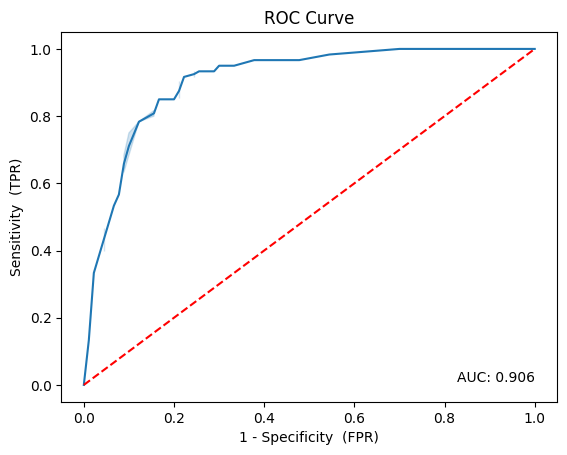

In [72]:
make_roc_curve(roc_info, "ROC Curve")
plt.show()

Our area under the curve (AUC) is 0.906. This is near 1, indicating that the model is quite good at differentiating between positive and negative heart disease cases. 

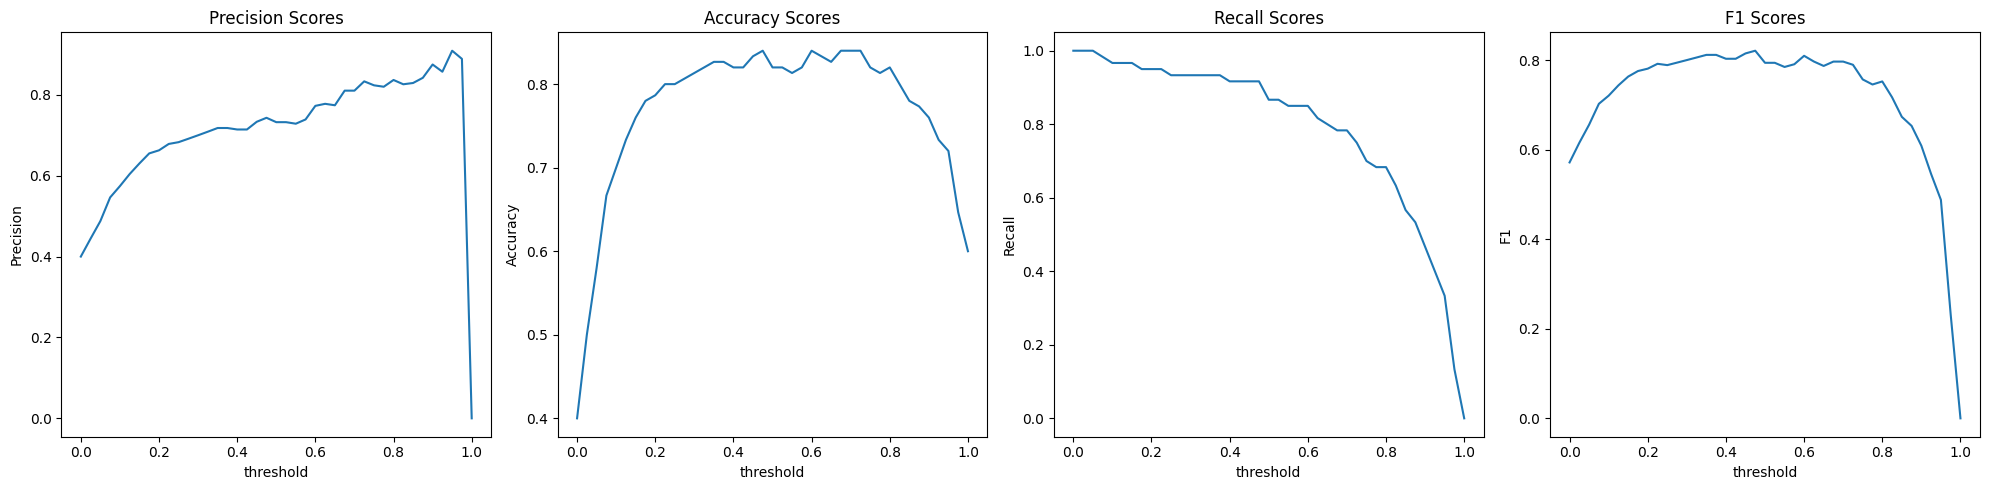

In [ ]:
fig, axes = plt.subplots(ncols = 4, nrows = 1, figsize=(20,5))
axes = axes.flatten()

l = other_scores.columns[1:5].tolist()
titles = ["Precision", "Accuracy", "Recall", "F1"]
for i in range(4):
  p = sns.lineplot(data = other_scores, x = "threshold", y = l[i], ax=axes[i], legend=False)
  axes[i].set_ylabel(titles[i])
  axes[i].set_title(titles[i]+" Scores")

plt.tight_layout()
plt.show()


Above is an overview of how our threshold choice impacts precision, accuracy, recall, and F1 scores. When looking at the F1 scores in conjunction accuracy, the figures suggest that we should retain a decision threshold of 0.5 as it offers the optimal balance between precision and recall.

Next, I am curious about the nature of influence of sex on heart disease. Some literature indicates that men and women experience heart disease symptoms for example differently, with women experiencing signs less obvious signs of heart disease in particular (Betai et al., 2024). . This made me wonder if the data set was split up to separate men and women, if we would find different variables to be significant in the datasets.

In [77]:
#split data frames by men and women
df_men = hd_df[hd_df.Sex == "M"]
df_women = hd_df[hd_df.Sex == "F"]

print("df men n: ", df_men.shape[0])
print("df women n: ", df_women.shape[0])

df men n:  564
df women n:  182


Evidently the women only data set is smaller, which may make it more difficult to have a female only model with many significant variables.

Next we will preprocess the data.

In [78]:
df_women_train, df_women_test = preprocessing(df_women)
print("\n")
df_men_train, df_men_test = preprocessing(df_men)

#drop sex column as it is now redundant
df_men_train = df_men_train.drop(columns=["Sex"])
df_women_train = df_women_train.drop(columns=["Sex"])

Columns undergoing one-hot encoding: ['ChestPainType', 'RestingECG', 'ST_Slope']
Dropping dummy variables:  ['ChestPainType_TA', 'ST_Slope_Flat', 'RestingECG_Normal']
Sex Classes (0, 1): ['F']
Angina Classes (0, 1): ['N' 'Y']
training data: n = 145
test data: n = 37


Columns undergoing one-hot encoding: ['ChestPainType', 'RestingECG', 'ST_Slope']
Dropping dummy variables:  ['ChestPainType_TA', 'ST_Slope_Flat', 'RestingECG_Normal']
Sex Classes (0, 1): ['M']
Angina Classes (0, 1): ['N' 'Y']
training data: n = 451
test data: n = 113


In [79]:
## First train male only data set

#1. get x variables
x_vars = list(df_men_train.drop(columns=["HeartDisease"]).columns)
x_vars = " + ".join(x_vars)
print("Input variables for logistic regression model:\n", x_vars, "\n")    #I will put these into the logistic regression model

#2. create the formula
f = "HeartDisease ~" + x_vars

#3. define model
HD_logit_men = smf.logit(formula = f, data = df_men_train).fit() #fit model to training data
print(HD_logit_men.summary()) 

Input variables for logistic regression model:
 Age + RestingBP + Cholesterol + FastingBS + MaxHR + ExerciseAngina + Oldpeak + ChestPainType_ASY + ChestPainType_ATA + ChestPainType_NAP + RestingECG_LVH + RestingECG_ST + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.297662
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  451
Model:                          Logit   Df Residuals:                      436
Method:                           MLE   Df Model:                           14
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.5662
Time:                        12:59:47   Log-Likelihood:                -134.25
converged:                       True   LL-Null:                       -309.49
Covariance Type:            nonrobust   LLR p-value:                 3.257e-66
                

Removing the insignificant variables we get a reduced model of:

In [80]:
#get x variables
men_remove = ["RestingECG_LVH", "RestingECG_ST", "MaxHR", "FastingBS", "Cholesterol", "RestingBP"]
x_vars = list(df_train.drop(columns=["HeartDisease"]+men_remove).columns)
x_vars = " + ".join(x_vars)
print("Input variables for logistic regression model:\n", x_vars, "\n")    #I will put these into the logistic regression model

#create the formula
f = "HeartDisease ~" + x_vars

#1 define model
HD_logit_men_red = smf.logit(formula = f, data = df_train).fit() #fit model to training data
print(HD_logit_men_red.summary()) 

Input variables for logistic regression model:
 Age + Sex + ExerciseAngina + Oldpeak + ChestPainType_ASY + ChestPainType_ATA + ChestPainType_NAP + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.317263
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  596
Model:                          Logit   Df Residuals:                      586
Method:                           MLE   Df Model:                            9
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.5423
Time:                        12:59:49   Log-Likelihood:                -189.09
converged:                       True   LL-Null:                       -413.10
Covariance Type:            nonrobust   LLR p-value:                 7.573e-91
                        coef    std err          z      P>|z|      [0.025      0.975]
---

This is our final model for the men only dataset.

Now to fit the model for the women only dataset.

In [81]:
#women only full model

#1. get x variables
drop_women = ["Age"]  #I had to drop 1 column to get the model to converge given the fewer data points (age was tested and found to be non-significant)
x_vars = list(df_women_train.drop(columns=["HeartDisease"]+drop_women).columns)
x_vars = " + ".join(x_vars)
print("Input variables for logistic regression model:\n", x_vars, "\n")    #I will put these into the logistic regression model

#2. create the formula
f = "HeartDisease ~" + x_vars

#3. define model
HD_logit_women = smf.logit(formula = f, data = df_women_train).fit() #fit model to training data
print(HD_logit_women.summary()) 

Input variables for logistic regression model:
 RestingBP + Cholesterol + FastingBS + MaxHR + ExerciseAngina + Oldpeak + ChestPainType_ASY + ChestPainType_ATA + ChestPainType_NAP + RestingECG_LVH + RestingECG_ST + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.220309
         Iterations 25
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  145
Model:                          Logit   Df Residuals:                      131
Method:                           MLE   Df Model:                           13
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.5755
Time:                        12:59:51   Log-Likelihood:                -31.945
converged:                       True   LL-Null:                       -75.246
Covariance Type:            nonrobust   LLR p-value:                 6.215e-13
                     

Now I will fit a reduced model containing only the significant variables for women.

In [82]:
#1. get x variables
drop_women = ["Age", "ChestPainType_NAP", "ChestPainType_ATA", "ChestPainType_ASY", "ExerciseAngina", "RestingECG_LVH", "RestingECG_ST", "Cholesterol", "MaxHR", "Oldpeak"] #remove insignificant columns
x_vars = list(df_women_train.drop(columns=["HeartDisease"]+drop_women).columns)
x_vars = " + ".join(x_vars)
print("Input variables for logistic regression model:\n", x_vars, "\n")    #I will put these into the logistic regression model

#2. create the formula
f = "HeartDisease ~" + x_vars

#3. define model
HD_logit_women_red = smf.logit(formula = f, data = df_women_train).fit() #fit model to training data
print(HD_logit_women_red.summary()) 

Input variables for logistic regression model:
 RestingBP + FastingBS + ST_Slope_Down + ST_Slope_Up 

Optimization terminated successfully.
         Current function value: 0.270512
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:                  145
Model:                          Logit   Df Residuals:                      140
Method:                           MLE   Df Model:                            4
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.4787
Time:                        12:59:53   Log-Likelihood:                -39.224
converged:                       True   LL-Null:                       -75.246
Covariance Type:            nonrobust   LLR p-value:                 8.400e-15
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------


As expected given the decreased size in data observations, there are fewer significant variables. Interestingly however, fasting blood sugar and resting blood pressure are indicative of heart disease in women but not in men, and not in the combined sex model. This finding does supports evidence from the literature that men and women have different symptoms of heart disease. In this case fasting blood sugar was a categorical variable, with 0 indicating a fasting BS of under 120 mg/dL and 1 indicating a fasting BS of over 120 mg/dL. Thus, having a fasting blood sugar over 120 mg/dL increases the odds of heart disease in women by $e^{3.0465} = 21.05$ times or approximatetly 2005%.<br><br>

Below is a Venn diagram showing overlap of significant variables in each of the three models.

In [83]:
#gathering info for the venn diagram
# first I will find the significant variables.
F = HD_logit_women_red.params.index[HD_logit_women_red.pvalues <= 0.05].tolist()
M = HD_logit_men_red.params.index[HD_logit_men_red.pvalues <= 0.05].tolist()
both = HD_logit_reduced.params.index[HD_logit_reduced.pvalues <= 0.05].tolist()

M.remove("Intercept")
both.remove("Intercept")

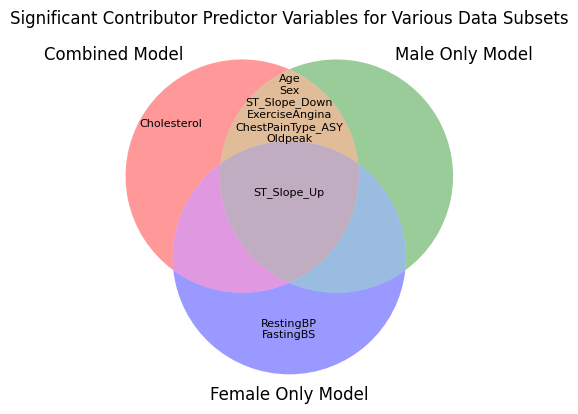

In [85]:
# Creating a venn diagram to compare significant predictors between models
male_only = set(M)
female_only = set(F)
combined_sex = set(both)

# Create the Venn
v = venn3(
          subsets=([3]*7),
          set_labels = ('Combined Model', 'Male Only Model', 'Female Only Model'),
        )

for text in v.subset_labels:
  if text:
    text.set_fontsize(8)
    # Move label upwards by adding to y coordinate
    x, y = text.get_position()
    text.set_position((x, y + 0.04))  # 0.05 moves it slightly up


#show the labels
# Add category names manually
v.get_label_by_id('100').set_text('\n'.join(combined_sex - male_only - female_only))      # only A
v.get_label_by_id('010').set_text('\n'.join(male_only - combined_sex - female_only))      # only B
v.get_label_by_id('001').set_text('\n'.join(female_only - combined_sex - male_only))      # only C
v.get_label_by_id('110').set_text('\n'.join(combined_sex & male_only - female_only))      # A & B
v.get_label_by_id('101').set_text('\n'.join(combined_sex & female_only - male_only))      # A & C
v.get_label_by_id('011').set_text('\n'.join(male_only & female_only - combined_sex))      # B & C
v.get_label_by_id('111').set_text('\n'.join(combined_sex & male_only & female_only))      # A & B & C

plt.title("Significant Contributor Predictor Variables for Various Data Subsets")
plt.show()

As you can see. Each heart disease predictor variable in the male only model is also present in the combined model. Meanwhile, there are 2 variables in the female only model: fasting blood sugar and resting blood pressure which are not significant in the combined model. This means that there are key predictive factors of heart disease which are specific to women only that could go unnoticed and likely give less accurate prediction results for women when the model is trained on men and women together. This highlights a disparaty for women and delivering accurate diagnoses and medical care to women in the health system.<br><br>

Cholesterol is likely only found in the combined model due to a larger number of observations allowing for more variables to be found significant. 
Interestingly, having an upward ST slope remains the most important predictor in diagnosis of a patient regardless of sex.<br><br>
We can further highlight the reduced accuracy of female diagnostic prediction by comparing the prediction accuracy between the combined, male only and female only model.

In [86]:
# Making predictions for male and female test sets using sex specific and combined models.

#1. predict women test set using women only model
F_pred_F_model = make_predictions(HD_logit_women_red, df_women_test, 0.5)
F_pred_F_model["actual"] = df_women_test.HeartDisease

#2. predict women test set using combined model
F_pred_combined_model = make_predictions(HD_logit_reduced, df_women_test, 0.5)
F_pred_combined_model["actual"] = df_women_test.HeartDisease

#3. predict male test set using male only model
M_pred_M_model = make_predictions(HD_logit_men_red, df_men_test, 0.5)
M_pred_M_model["actual"] = df_men_test.HeartDisease

#4. predict male test using combined model
M_pred_combined_model = make_predictions(HD_logit_reduced, df_men_test, 0.5)
M_pred_combined_model["actual"] = df_men_test.HeartDisease


In [88]:
#calculating precision, accuracy, recall, and f1 for all model predictions
F_F_metrics = metric_scores(F_pred_F_model.actual, F_pred_F_model.pred, "F_F")
F_both_metrics = metric_scores(F_pred_combined_model.actual, F_pred_combined_model.pred, "F_both")
M_M_metrics = metric_scores(M_pred_M_model.actual, M_pred_M_model.pred, "M_M")
M_both_metrics = metric_scores(M_pred_combined_model.actual, M_pred_combined_model.pred, "M_both")

#adding data from the model on both datasets for comparison
both_both = other_scores[round(other_scores.threshold,2) == 0.50]
both_both.loc[0, "model"] = "both_both"

#combine all dataframes
all_metrics_df = pd.concat([F_F_metrics, F_both_metrics, M_M_metrics, M_both_metrics, both_both]).drop(columns=["threshold"])
#all_metrics_df



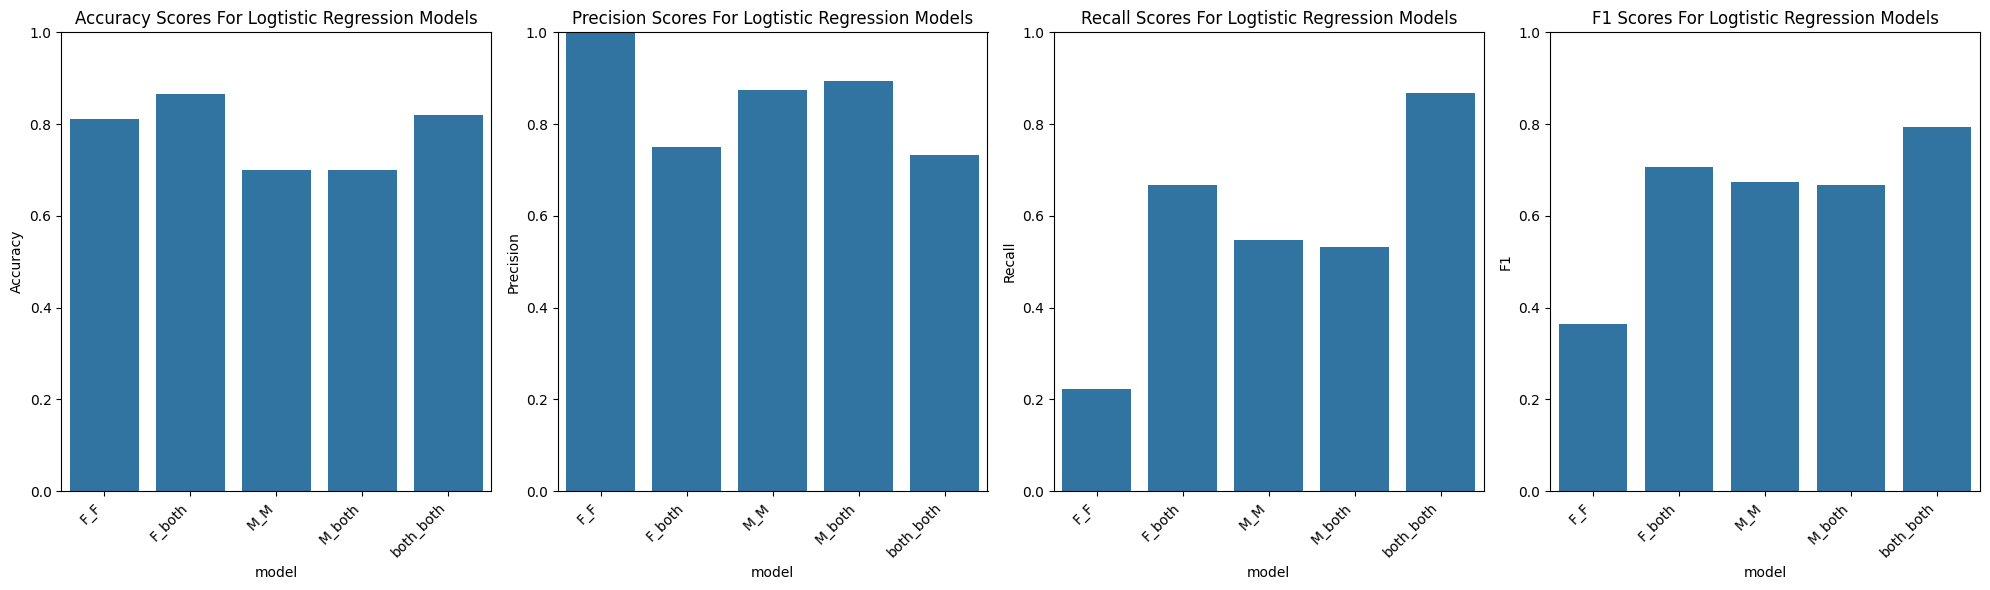

In [89]:
#plot changes in accuracy/precision
fig, axes = plt.subplots(ncols = 4, nrows = 1, figsize=(20,6))
axes = axes.flatten()

l = ["ac", "pr", "rc", "f1"]
titles = ["Accuracy", "Precision", "Recall", "F1"]
for i in range(4):
  p = sns.barplot(data = all_metrics_df, x = "model", y = l[i], ax=axes[i], legend=False)
  plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')
  axes[i].set_ylim(0,1)
  axes[i].set_ylabel(titles[i])
  axes[i].set_title(titles[i]+" Scores For Logtistic Regression Models")


plt.tight_layout()
plt.show()

As you can see when the female only model is making predictions on the female (F_F) only dataset, accuracy, recall, and F1 scores are actually lower than when using the combined sex model (F_both), contrary to what was expeected. This is probably due to the combined sex model having more observations to be trained on in general, Thus, to increase heart disease prediction accuracy for women, we would need more observations for the women only model. In comparison, the male only model predicting on the male only dataset (M_M) has similar scores to that of the combined sex model on the male only dataset (M_both), further showing that the larger proportion of men in the dataset is biasing the combined sex model to making more accurate predictions for men, while forgoing female heart prediction accuracy. The combined sex model predicting for the combined test dataset (both_both) is also shown for comparison.

Ultimately, sex has a complex influence on heart disease and the health and environmental variables which contribute to it. Women and men have unique biologies which are reflected in their partially unique heart disease symptoms. To reduce gender disparity in the healthcare system, it is important that researchers continue to recognize the biological differences between men and women and perform their research accordingly. Furthermore, in the era of machine learning and AI, a greater emphasis should be placed on developing and evaluating sex-specific models to ensure equitable performance across populations. Such approaches have the potential to improve diagnostic accuracy and provide more personalized and effective healthcare for future patients.

<h2>References</h2>

Al Ahdal, A., Rakhra, M., Rajendran, R. R., Arslan, F., Khder, M. A., Patel, B., Rajagopal, B. R., & Jain, R. (2023). *Monitoring cardiovascular problems in heart patients using machine learning* [Article]. Journal of Healthcare Engineering, 2023, Article 9738123. https://doi.org/10.1155/2023/9738123

American Heart Association. (2024a, August 12). *Target heart rates chart.* https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates

American Heart Association. (2024b, December 11). *Ischemic heart disease and silent ischemia.* https://www.heart.org/en/health-topics/heart-attack/about-heart-attacks/silent-ischemia-and-ischemic-heart-disease

American Heart Association. (2025, August 14). *Understanding blood pressure readings.* https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings

Betai, D., Ahmed, A. S., Saxena, P., Rashid, H., Patel, H., Shahzadi, A., Mowo-wale, A. G., & Nazir, Z. (2024). Gender Disparities in Cardiovascular Disease and Their Management: A Review. Cureus, 16(5), e59663. https://doi.org/10.7759/cureus.59663

Burns, E., & Buttner, R. (2024, October 8).*The ST segment.* LITFL ECG Library. https://litfl.com/st-segment-ecg-library/

Cabot, J. H., & Ross, E. G. (2023). *Evaluating prediction model performance.* Surgery, 174(5), 723–726. https://doi.org/10.1016/j.surg.2023.05.023

Cleveland Clinic. (2022). *Chambers of the heart* [Illustration]. Cleveland Clinic. https://my.clevelandclinic.org/health/body/23074-heart-chambers

Dancy, L., O'Gallagher, K., Milton, P., & Sado, D. (2018). *New NICE guidelines for the management of stable angina.* British Journal of General Practice, 68(669), 202–203. https://doi.org/10.3399/bjgp18X695693

Fedesoriano. (2021). *Heart failure prediction dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Johns Hopkins Medicine. (2025). *Lipid panel.* https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel

MicrobeNotes. (2024). *Electrocardiogram (ECG)* [Image]. MicrobeNotes. https://microbenotes.com/wp-content/uploads/2023/09/Electrocardiogram-ECG.jpeg

Park, C., Guallar, E., Linton, J. A., Lee, D. C., Jang, Y., Son, D. K., Han, E. J., Baek, S. J., Yun, Y. D., Jee, S. H., & Samet, J. M. (2013). *Fasting glucose level and the risk of incident atherosclerotic cardiovascular diseases.* Diabetes Care, 36(7), 1988–1993. https://doi.org/10.2337/dc12-1577

Ranganathan, P., Pramesh, C. S., & Aggarwal, R. (2017). *Common pitfalls in statistical analysis: Logistic regression.* Perspectives in Clinical Research, 8(3), 148–151. https://doi.org/10.4103/picr.PICR_87_17

Walamies, M. A., Kööbi, T., Hämäläinen, L. I., & Ahonen, E. A. (2000). *Visual versus computerized analysis of upsloping ST segment depression in the exercise electrocardiogram*. Cardiology, 92(4), 264–268. https://doi.org/10.1159/000006984

Yazdani, A., Varathan, K. D., Chiam, Y. K., Malik, A. W., & Ahmad, W. A. W. (2021). *A novel approach for heart disease prediction using strength scores with significant predictors.* BMC Medical Informatics and Decision Making, 21(1), 194. https://doi.org/10.1186/s12911-021-01527-5